# Visualize Latents with ActMax

### Imports

In [1]:
import sys, os 
# sys.path.append(os.path.abspath('.'))

import torch
import torchaudio
import numpy as np
import gin
import rave
import types
import act_max_util as amu # no PCA
# import act_max_pca as amu # with PCA
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F

/Users/DiarmuidFogarty/repos/XRAVE/act_max_util.py:236: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if Gaussian_Blur and k % theta_every is 0:


### Plotting functions

In [2]:
def plot_mel_spectrogram(mel_spectrogram, title='Mel Spectrogram', dB_scale=True, save_path=None):
    # Remove batch dimension if present
    if mel_spectrogram.dim() == 3 and mel_spectrogram.size(0) == 1:
        mel_spectrogram = mel_spectrogram[0]
    
    if dB_scale:
        mel_spectrogram = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram)
        
    else:
        # Normalize mel spectrogram to [0, 1] range
        mel_min = mel_spectrogram.min()
        mel_max = mel_spectrogram.max()
        if mel_max == mel_min:  # Avoid division by zero
            mel_spectrogram = mel_spectrogram - mel_min
        else:     # Normalize to [0, 1]
            mel_spectrogram = (mel_spectrogram - mel_min) / (mel_max - mel_min)

    plt.figure(figsize=(8, 7))
    plt.imshow(mel_spectrogram, origin="lower", aspect="auto", cmap="magma")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    if dB_scale:
        plt.colorbar(format="%+2.0f dB")
    else:
        plt.colorbar(label="Amplitude")
    if save_path:
        plt.savefig(save_path)
    plt.show()

### Override custom padding in `cached_conv` package

In [3]:
# Not sure of a clean way to do this yet without directly modifying the original package

### Load model

In [15]:
# Directory containing model checkpoint and config
model_dir = './checkpoints/noise_warmup_200k_latent_8'

# Load the model
config_path = rave.core.search_for_config(model_dir)
gin.parse_config_file(config_path)
model = rave.RAVE()
run = rave.core.search_for_run(model_dir)
model = model.load_from_checkpoint(run)


print(f'Model loaded from {model_dir}')
print(f'model.latent_size: {model.latent_size}')

model

Model loaded from ./checkpoints/noise_warmup_200k_latent_8
model.latent_size: 8


RAVE(
  (pqmf): CachedPQMF(
    (forward_conv): Conv1d(1, 16, kernel_size=(513,), stride=(16,), bias=False)
    (inverse_conv): Conv1d(16, 16, kernel_size=(33,), stride=(1,), bias=False)
  )
  (spectrogram): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (encoder): VariationalEncoder(
    (encoder): EncoderV2(
      (net): CachedSequential(
        (0): Conv1d(128, 96, kernel_size=(7,), stride=(1,), bias=False)
        (1): Residual(
          (aligned): Branches(
            (branches): ModuleList(
              (0): DilatedUnit(
                (net): CachedSequential(
                  (0): LeakyReLU(negative_slope=0.2)
                  (1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), bias=False)
                  (2): LeakyReLU(negative_slope=0.2)
                  (3): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
                )
              )
              (1): Identity()
            )
          )
        )
        (2): Leaky

### Initialize input

initial_mel.shape: torch.Size([1, 128, 8])
tensor([[-0.6192,  0.1928,  0.7884, -0.3155,  2.2240,  0.7546,  0.0760, -0.7787,
         -0.4355, -0.2518,  1.2479,  0.6470, -0.2396,  1.3378,  0.8853,  2.2522,
          0.0634,  0.7601, -2.6630,  1.4285,  0.4285,  0.6749, -2.0253,  0.9511,
         -0.4267,  1.5626,  0.6072, -0.3642, -0.9234,  0.7025, -0.0392, -2.5481,
         -0.0930, -1.1840,  0.7362, -2.6599,  0.1960,  1.3675, -0.4713, -0.8730,
          0.4606,  0.3066, -0.3560,  1.6867,  1.3728,  0.6896, -1.6673, -0.2253,
          0.3664, -0.1983, -0.0649,  0.1903, -1.4476,  0.7757, -1.0900, -1.1465,
          1.2245, -0.6960, -0.1347, -0.6385, -0.4196, -0.8561,  0.2895,  0.8428,
          1.2172,  1.1747,  0.6732,  0.0936, -1.5764, -0.0481,  0.6750,  0.6507,
         -1.0490, -0.7248,  1.3204,  0.1794,  0.4062,  0.0278, -0.0038, -0.4981,
          1.4560,  0.7118,  3.1499,  0.4204, -0.0893, -0.0701, -0.9438,  0.7178,
          0.8082,  1.0008, -0.3733, -1.4834, -0.3309, -0.2510,  1.

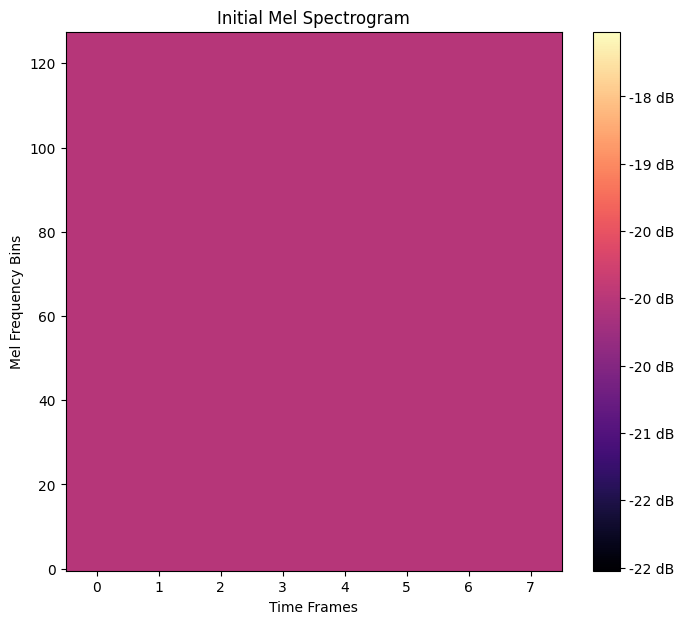

In [5]:
# Create placeholder spectrogram input
n_mels = 128
C = 8 # compression ratio of encoder based on strides

initial_mel = torch.randn((1, n_mels, C))
print(f'initial_mel.shape: {initial_mel.shape}')
print(initial_mel[:, :, 0])
initial_mel[:, :, :] = 10e-3 # NOTE: too small magnitude may lead to negatives in final optimal spectrogram

input = torch.log1p(initial_mel) # log scaling like in RAVE _mel_encode()

plot_mel_spectrogram(input, title='Initial Mel Spectrogram', dB_scale=True)

### Plot PCA component

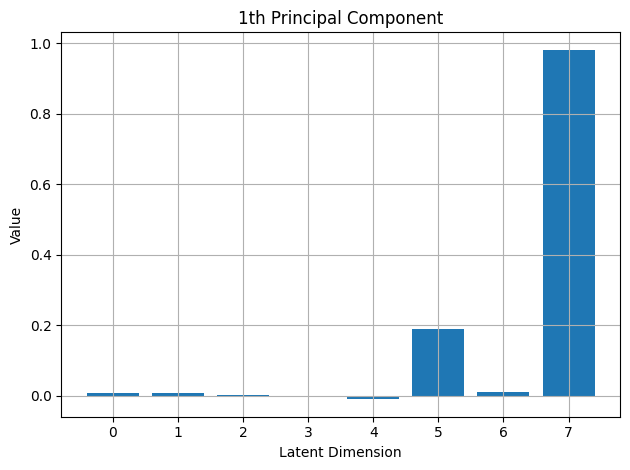

In [6]:
N = 0
pc = model.latent_pca[N]

plt.bar(np.arange(len(pc)), pc)
plt.title(f'{N+1}th Principal Component')
plt.xlabel('Latent Dimension')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### Create hook into final encoder layer

In [7]:
# Create hook into target layer
output_layer_encoder = model.encoder.encoder.net[-1]  # NOTE: (means, scales): (128,128)
layer_name = 'output_layer_encoder'
act_dict = {}
output_layer_encoder.register_forward_hook(amu.layer_hook(act_dict, layer_name))

### Prepare optimization

In [8]:
input.requires_grad_(True)  # enable gradient computation

# Parameters for activation maximization
steps = 200               # perform 100 iterations
units = range(model.latent_size)     # take all latents
alpha = torch.tensor(0.05)   # learning rate (step size) 
verbose = True              # print activation every step
L2_Decay = False             # enable L2 decay regularizer
Gaussian_Blur = True        # enable Gaussian regularizer
Norm_Crop = False            # enable norm regularizer
Contrib_Crop = False         # enable contribution regularizer

pc = -pc # choose direction of PC to maximize

### Run ActMax

In [9]:
# Run activation maximization
output = amu.act_max(
    network=model,
    input=input,
    layer_activation=act_dict,
    layer_name=layer_name,
    units=units,
    steps=steps,
    alpha=alpha,
    verbose=verbose,
    L2_Decay=L2_Decay,
    Gaussian_Blur=Gaussian_Blur,
    Norm_Crop=Norm_Crop,
    Contrib_Crop=Contrib_Crop,
    update_viz=True,
    pc=pc
)

step:  0 activation:  tensor(-0.1452, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9653, grad_fn=<DivBackward0>)
step:  1 activation:  tensor(-0.1210, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9641, grad_fn=<DivBackward0>)
step:  2 activation:  tensor(-0.0890, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9600, grad_fn=<DivBackward0>)
step:  3 activation:  tensor(-0.0552, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9476, grad_fn=<DivBackward0>)
step:  4 activation:  tensor(-0.0247, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9030, grad_fn=<DivBackward0>)
step:  5 activation:  tensor(-0.0280, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9320, grad_fn=<DivBackward0>)
step:  6 activation:  tensor(-0.0037, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.8209, grad_fn=<DivBackward0>)
step:  7 activation:  tensor(-0.0013, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.9507, grad_fn=<DivBackward0>)
step:  8 activation:  tensor(-0.0004, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.3415, grad_fn=<DivBack

### Check latent trajectory for concatenated output

output.shape before flattening: torch.Size([1, 128, 8])


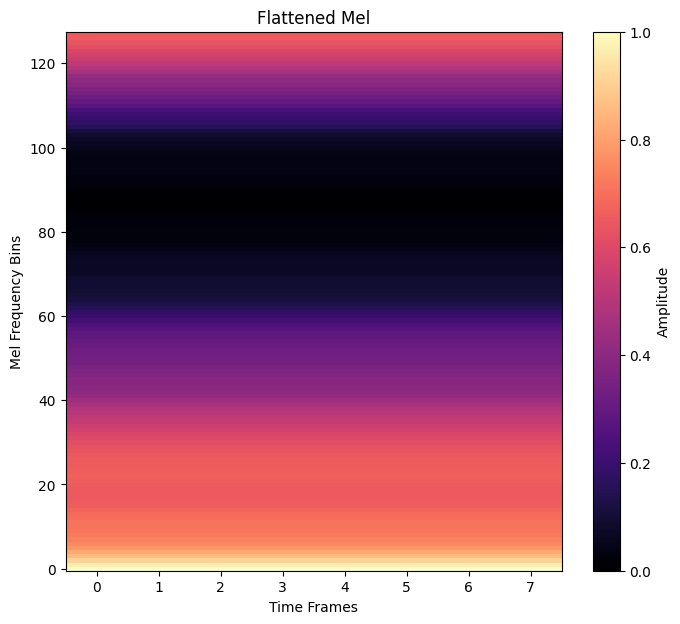

In [13]:
# [Experimental] Try setting each entry to the average of the amplitudes across all time frames
print(f'output.shape before flattening: {output.shape}')
mel_avg = output.mean(dim=2, keepdim=True)
mel_flat = mel_avg.expand(-1, -1, output.size(2))
plot_mel_spectrogram(mel_flat.detach(), title='Flattened Mel', dB_scale=False)
output = mel_flat

output_concat.shape: torch.Size([1, 128, 80])
Value range: -0.3630177080631256 to 0.1173778772354126


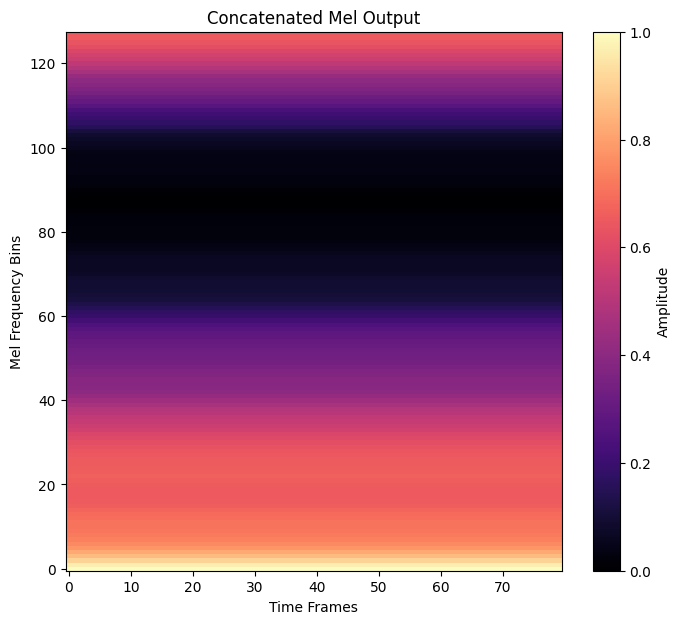

In [14]:
# Concatenate output multiple times to see latent trajectory
n = 10

output_concat = torch.cat([output]*n, dim=-1)
print(f'output_concat.shape: {output_concat.shape}')
print(f'Value range: {torch.min(output_concat)} to {torch.max(output_concat)}')
plot_mel_spectrogram(output_concat.detach(), title='Concatenated Mel Output', dB_scale=False)

z_enc.shape: torch.Size([1, 16, 10])


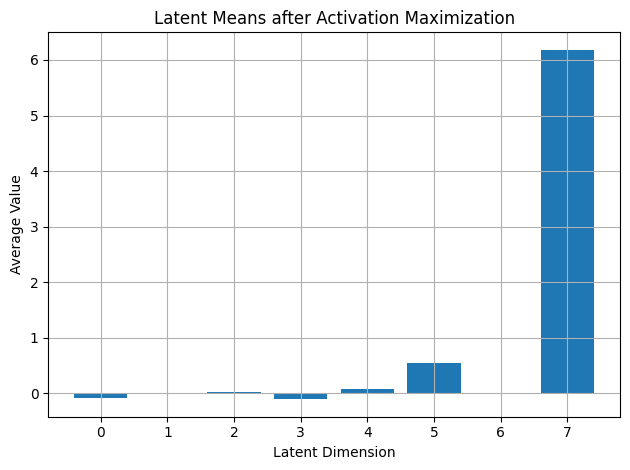

In [16]:
def plot_latent_means(latent_means, title='Latent Means', save_path=None):
    """
    Plots the average value of each latent mean across time frames.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    averages = latent_means.squeeze(0).mean(dim=1).detach()  # Average over time frames
    plt.bar(np.arange(len(averages)), averages)
    plt.title(title)
    plt.xlabel('Latent Dimension')
    plt.ylabel('Average Value')
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


z_enc = model.encoder(output_concat)
means, logscales = torch.split(z_enc, z_enc.shape[1] // 2, 1)
print(f'z_enc.shape: {z_enc.shape}')
plot_latent_means(means, title='Latent Means after Activation Maximization')

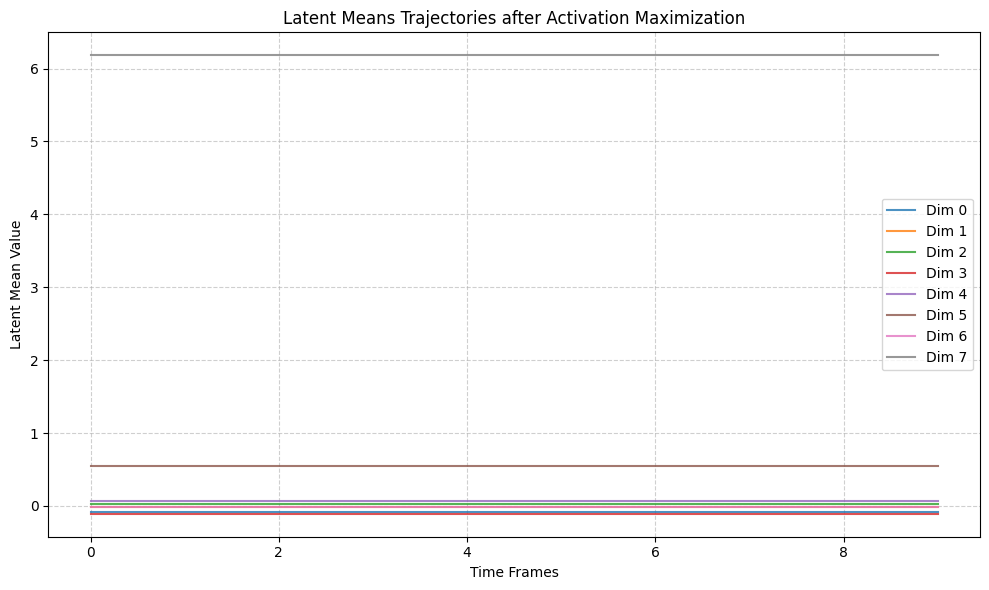

In [17]:
def plot_latent_trajectories(
    latent_means,
    title='Latent Means Trajectories',
    save_path=None
):
    """
    Plots the trajectories of latent means over time using step plots.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    latent_np = latent_means.squeeze(0).cpu().detach().numpy()
    T = latent_np.shape[1]  # number of timesteps

    plt.figure(figsize=(10, 6))
    for dim in range(latent_np.shape[0]):
        plt.step(
            range(T),
            latent_np[dim, :],
            where='mid',
            alpha=0.8,
            label=f'Dim {dim}'
        )

    plt.title(title)
    plt.xlabel('Time Frames')
    plt.ylabel('Latent Mean Value')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    
plot_latent_trajectories(means, title='Latent Means Trajectories after Activation Maximization')